In [2]:
import sys
sys.path.insert(0, '..')  # so `from nanograd...` works from notebooks/ folder

import matplotlib.pyplot as plt
import random

# 07 — Minimal Character-Level Next-Token Prediction with Attention

In this notebook you will train a tiny decoder-style model using the `SelfAttentionHead` you built.

**Goal**: Predict the next character in a tiny repeated text corpus.

This gives you a real, relevant use case (on-device LLM style training) that you personally run and understand.

Total expected time: 2-4 hours of focused work, including studying the code.

## 1. Choose your tiny corpus

We will use a very small repeated phrase so the model can actually learn patterns quickly.

Recommended starting corpus (feel free to change it):

In [3]:
corpus = "AI should run Locally AI should run Locally AI should run Locally AI should run Locally AI should run Locally"
print(f'Corpus length: {len(corpus)} chars')
print(f'Unique chars: {sorted(set(corpus))}')

Corpus length: 109 chars
Unique chars: [' ', 'A', 'I', 'L', 'a', 'c', 'd', 'h', 'l', 'n', 'o', 'r', 's', 'u', 'y']


## 2. Build vocabulary and prepare data

We create a simple character-level vocabulary.

In [4]:
chars = sorted(list(set(corpus)))
vocab_size = len(chars)
char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for i, c in enumerate(chars)}

print(f'Vocab size: {vocab_size}')
print(f'Vocab: {chars}')
# print("char_to_idx : ",char_to_idx)
# print("idx_to_char : ",idx_to_char)

Vocab size: 15
Vocab: [' ', 'A', 'I', 'L', 'a', 'c', 'd', 'h', 'l', 'n', 'o', 'r', 's', 'u', 'y']


## 3. Define model hyperparameters

Keep them small so everything runs fast on CPU.

In [5]:
T = 8           # sequence length (context window)
n_embed = 8     # embedding / model dimension
head_size = 4   # attention head size
num_classes = vocab_size

print(f'T={T}, n_embed={n_embed}, head_size={head_size}, vocab_size={vocab_size}')

T=8, n_embed=8, head_size=4, vocab_size=15


## 4. Prepare training examples

We slide a window of size T over the corpus and predict the next character.

In [6]:
def build_dataset(corpus, T):
    X, y = [], []
    for i in range(len(corpus) - T):
        context = corpus[i:i+T]
        target = corpus[i+T]
        X.append([char_to_idx[c] for c in context])
        y.append(char_to_idx[target])
    return X, y

X, y = build_dataset(corpus, T)
print(f'Number of training examples: {len(X)}')
print(f'Example X[0] = {X[0]} -> y[0] = {y[0]} ({idx_to_char[y[0]]})')

Number of training examples: 101
Example X[0] = [1, 2, 0, 12, 7, 10, 13, 8] -> y[0] = 6 (d)


## 5. The Model

We reuse `SelfAttentionHead` and add a simple linear classifier on top of the attended representation.

For simplicity we use the first token's output as the pooled representation (it has attended to the entire context).

In [7]:
from nanograd.tensor import Tensor
from nanograd.attention import SelfAttentionHead
from nanograd.nn import MLP
from nanograd.ops import cross_entropy
from nanograd.engine import Value

class TinyCharLM:
    def __init__(self, vocab_size, n_embed, head_size):
        self.head = SelfAttentionHead(n_embed, head_size)
        self.classifier = MLP(head_size, [vocab_size])
    
    def __call__(self, X):  # X: Tensor (T, n_embed)
        out, weights = self.head(X)
        # Use first token's output as pooled representation
        pooled = out.data[0]   # list of Values, length head_size
        logits = self.classifier(pooled)
        # print("logits = ",logits)
        return logits, weights
    
    def parameters(self):
        return self.head.parameters() + self.classifier.parameters()
    
    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0

model = TinyCharLM(vocab_size, n_embed, head_size)
print(f'Total parameters: {len(model.parameters())}')

Total parameters: 171


## 6. Training Loop

Standard loop. You can study and modify the learning rate, number of epochs, etc.

In [10]:
import random
import math

# Simple learnable embedding table
embedding = [Value(random.gauss(0, 0.1)) for _ in range(vocab_size * n_embed)]

lr = 0.1          # ← lowered from 0.5
epochs = 200
losses = []

def clip_grad(p, max_norm=5.0):
    if p.grad > max_norm:  p.grad = max_norm
    if p.grad < -max_norm: p.grad = -max_norm

for epoch in range(epochs):
    total_loss = Value(0.0)
    
    for context_indices, target_idx in zip(X, y):
        # Build (T, n_embed) input
        rows = []
        for idx in context_indices:
            start = idx * n_embed
            row = embedding[start : start + n_embed]
            rows.append(row)
        X_tensor = Tensor(rows)
        
        logits, _ = model(X_tensor)
        total_loss = total_loss + cross_entropy(logits, target_idx)
    
    avg_loss = total_loss / len(X)
    
    # Zero grads
    model.zero_grad()
    for v in embedding:
        v.grad = 0.0
    
    avg_loss.backward()
    
    # Update model parameters + clip
    for p in model.parameters():
        clip_grad(p)
        p.data -= lr * p.grad
    
    # Update embedding table + clip
    for v in embedding:
        clip_grad(v)
        v.data -= lr * v.grad
        v.grad = 0.0
    
    losses.append(avg_loss.data)
    if epoch % 10 == 0 or epoch == epochs - 1:
        print(f'epoch {epoch:3d}  loss = {avg_loss.data:.4f}')

print(f'\nfinal loss = {losses[-1]:.4f}')

epoch   0  loss = 2.8605
epoch  10  loss = 2.5303
epoch  20  loss = 2.3052
epoch  30  loss = 2.1044
epoch  40  loss = 1.8707
epoch  50  loss = 1.6666
epoch  60  loss = 1.5673
epoch  70  loss = 1.4913
epoch  80  loss = 1.4275
epoch  90  loss = 1.3777
epoch 100  loss = 1.3368
epoch 110  loss = 1.2987
epoch 120  loss = 1.2602
epoch 130  loss = 1.2198
epoch 140  loss = 1.1762
epoch 150  loss = 1.1289
epoch 160  loss = 1.0785
epoch 170  loss = 1.0280
epoch 180  loss = 0.9805
epoch 190  loss = 0.9375
epoch 199  loss = 0.9021

final loss = 0.9021


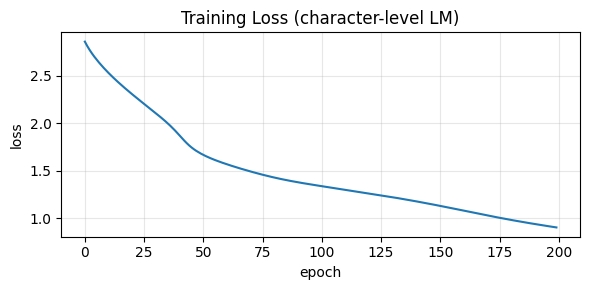

In [12]:
import matplotlib.pyplot as plt
import random
plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.title('Training Loss (character-level LM)')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('07_loss_curve.png', dpi=150)
plt.show()

In [13]:
print("Example predictions after training:\n")

# Pick a few contexts from the dataset
sample_indices = [0, 10, 25, 40]

for i in sample_indices:
    context = X[i]
    target = y[i]
    
    # Build tensor
    rows = []
    for idx in context:
        start = idx * n_embed
        row = embedding[start : start + n_embed]
        rows.append(row)
    X_tensor = Tensor(rows)
    
    # Forward
    logits, weights = model(X_tensor)
    
    # Softmax to get probabilities
    probs = [math.exp(l.data) for l in logits]
    s = sum(probs)
    probs = [p / s for p in probs]
    
    # Top prediction / could also do argmax 
    pred_idx = max(range(len(probs)), key=lambda k: probs[k])
    pred_char = idx_to_char[pred_idx]
    true_char = idx_to_char[target]
    
    context_str = ''.join(idx_to_char[c] for c in context)
    print(f"Context: '{context_str}'  →  Predicted: '{pred_char}'  (true: '{true_char}')")

Example predictions after training:

Context: 'AI shoul'  →  Predicted: 'd'  (true: 'd')
Context: 'run Loca'  →  Predicted: 'l'  (true: 'l')
Context: 'should r'  →  Predicted: 'u'  (true: 'u')
Context: 'lly AI s'  →  Predicted: 'o'  (true: 'h')
